Theta 0 (Intercept): 0.0408
Theta 1 (Slope): 2.9994
Predicted price for 70m2: 210.00


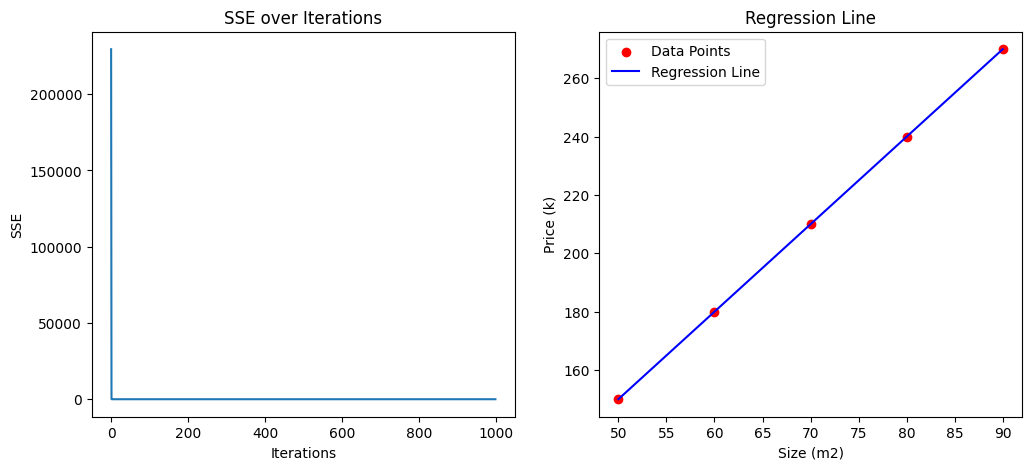

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []

    def fit(self, X, y):
        n = len(y)
        for _ in range(self.n_iters):
       
            y_pred = self.theta_0 + self.theta_1 * X
            
           
            sse = np.sum((y - y_pred) ** 2)
            self.sse_history.append(sse)
            
            
            d_theta_0 = (-2/n) * np.sum(y - y_pred)
            d_theta_1 = (-2/n) * np.sum((y - y_pred) * X)
            
        
            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

    def plot_training(self, X, y):
        plt.figure(figsize=(12, 5))

      
        plt.subplot(1, 2, 1)
        plt.plot(range(self.n_iters), self.sse_history)
        plt.title('SSE over Iterations')
        plt.xlabel('Iterations')
        plt.ylabel('SSE')

       
        plt.subplot(1, 2, 2)
        plt.scatter(X, y, color='red', label='Data Points')
        plt.plot(X, self.predict(X), color='blue', label='Regression Line')
        plt.title('Regression Line')
        plt.xlabel('Size (m2)')
        plt.ylabel('Price (k)')
        plt.legend()
        plt.show()




X = np.array([50, 60, 70, 80, 90]) # [cite: 8, 12]
y = np.array([150, 180, 210, 240, 270]) # [cite: 10, 12]


model = LinearRegressionGD(learning_rate=0.0001, n_iters=1000) 
model.fit(X, y)


print(f"Theta 0 (Intercept): {model.theta_0:.4f}")
print(f"Theta 1 (Slope): {model.theta_1:.4f}")


size_to_predict = 70
predicted_price = model.predict(size_to_predict)
print(f"Predicted price for 70m2: {predicted_price:.2f}")


model.plot_training(X, y)